<a href="https://colab.research.google.com/github/Renata-Correa/Sprint_Machine_Learning_e_Analytics/blob/main/PUC_RJ_Renata_Corr%C3%AAa_Marchine_Learning_%26_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 PUC-Rio | Pós-Graduação em Ciencia de Dados e Analytics


👩🏼‍💻 MVP - Machine Learning & Analytics

**Nome:** Renata Corrêa

**Matrícula:** 4052025000032

**Data:** 04/07/2026

**Dataset:** [Campeonato Brasileiro Série A ](https://raw.githubusercontent.com/Renata-Correa/Sprint_Analise_de_Dados_e_Boas_Praticas/96d7cc53dbfb1b2f0286d580f8cb493d24984e4d/campeonato-brasileiro-full.csv)


#🏆 Análise do Brasileirão Série A

##🎯 Definição do Problema

O futebol brasileiro é caracterizado por alta competitividade e variações de desempenho entre equipes ao longo das temporadas.

Este projeto tem como objetivo analisar dados históricos do Campeonato Brasileiro Série A para entender padrões de desempenho, com foco especial no chamado **"fator casa"**, além de métricas ofensivas e defensivas.

##🧩 Pergunta Central

- Quais fatores influenciam o resultado das partidas no Brasileirão?

##❓ Perguntas de Negócio

- O fator casa influencia significativamente o resultado das partidas?
- Times com melhor ataque necessariamente vencem mais?
- Existe relação entre defesa sólida e pontuação?
- Como o desempenho evolui ao longo das temporadas
- Sofrer menos gols está associado a melhor desempenho?
- Existe diferença significativa entre jogar em casa e fora?

##🧭 Respondendo no Código

| Pergunta             | Técnica               |
| -------------------- | --------------------- |
| Fator Casa           | proporção de vitórias |
| Ataque vs Vitória    | correlação            |
| Defesa vs Desempenho | agregações            |
| Casa vs Fora         | comparação            |
| Evolução             | séries temporais      |
| Previsão             | Machine Learning      |


##🤖 Tipo de Problema

Este é um problema de:

➡️ **Aprendizado NÃO supervisionado**

Não estou prevendo diretamente um resultado, mas sim **extraindo padrões e insights dos dados.**

##🧠 Hipóteses

- Times jogando em casa têm maior probabilidade de vitória
- Times com mais gols marcados tendem a vencer mais
- Defesas mais sólidas estão associadas a melhor desempenho geral

##⚠️ Restrições

- Dados históricos disponíveis no dataset
- Possíveis inconsistências ou dados faltantes
- Não há informações detalhadas como posse de bola ou escalações

##📊 Descrição dos Atributos

- HomeTeam: Time mandante
- AwayTeam: Time visitante
- HomeGoals: Gols do mandante
- AwayGoals: Gols do visitante
- Date: Data da partida
- Season: Temporada

#🔎 ANÁLISE EXPLORATÓRIA

##📦 Importação de Bibliotecas

In [222]:
import pandas as pf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Configuração Visual
sns.set(style="whitegrid")

##📂 Carregamento dos Dados

In [223]:
url = "https://raw.githubusercontent.com/Renata-Correa/Sprint_Analise_de_Dados_e_Boas_Praticas/96d7cc53dbfb1b2f0286d580f8cb493d24984e4d/campeonato-brasileiro-full.csv"

df = pf.read_csv(url)

df.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP


##🎲 Estrutura dos Dados

Nesta etapa, analisamos a estrutura dos dados para entender seus tipos e consistência.

In [224]:
print(df.shape)
df.info()

(8785, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8785 entries, 0 to 8784
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  8785 non-null   int64 
 1   rodata              8785 non-null   int64 
 2   data                8785 non-null   object
 3   hora                8785 non-null   object
 4   mandante            8785 non-null   object
 5   visitante           8785 non-null   object
 6   formacao_mandante   3810 non-null   object
 7   formacao_visitante  3810 non-null   object
 8   tecnico_mandante    4175 non-null   object
 9   tecnico_visitante   4175 non-null   object
 10  vencedor            8785 non-null   object
 11  arena               8785 non-null   object
 12  mandante_Placar     8785 non-null   int64 
 13  visitante_Placar    8785 non-null   int64 
 14  mandante_Estado     8785 non-null   object
 15  visitante_Estado    8785 non-null   object
dtypes: int64(4), 

##📈 Estatísticas Descritivas
Observações:
- A média de gols por partida gira em torno de valores típicos do futebol (baixo número de gols).
- Existem partidas com valores mais elevados (possíveis outliers).
- A distribuição parece assimétrica, com concentração em poucos gols.

In [225]:
display(df.describe(include='all'))

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
count,8785.000000,8785.000000,8785,8785,8785,8785,3810,3810,4175,4175,8785,8785,8785.000000,8785.000000,8785,8785
unique,NaN,NaN,2052,189,45,45,22,21,237,241,46,168,NaN,NaN,15,15
top,NaN,NaN,06/07/2008,16:00,Flamengo,Fluminense,4-2-3-1,4-2-3-1,L. Venker de Menezes,L. Venker de Menezes,-,Maracanã,NaN,NaN,SP,SP
freq,NaN,NaN,15,1930,428,428,2182,2046,141,144,2322,669,NaN,NaN,2173,2173
mean,4393.000000,20.105862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.535572,1.027319,NaN,NaN
std,2536.155391,11.425072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.225262,1.025264,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,2197.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN
50%,4393.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
75%,6589.000000,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN


##⚠️ Valores Faltantes

Não há quantidade relevante de valores faltantes, o que indica boa qualidade do dataset.

In [226]:
display(df.isnull().sum())

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,4975
formacao_visitante,4975
tecnico_mandante,4610
tecnico_visitante,4610


##🔍 Análise Inicial

In [227]:
df["TotalGols"]=df["mandante_Placar"]+df["visitante_Placar"]
df["Resultado"]=np.where(df["mandante_Placar"]>df["visitante_Placar"],"Casa",np.where(df["mandante_Placar"]<df["visitante_Placar"],"Visitante","Empate"))
df.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,TotalGols,Resultado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,6,Casa
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,2,Casa
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,2,Empate
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,4,Empate
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,2,Empate


# 🧮 VISUALIZAÇÕES

##📊 Distribuição de Gols

A maior parte das partidas apresenta poucos gols, geralmente entre 0 e 3.  
Partidas com muitos gols são raras e podem ser consideradas exceções.

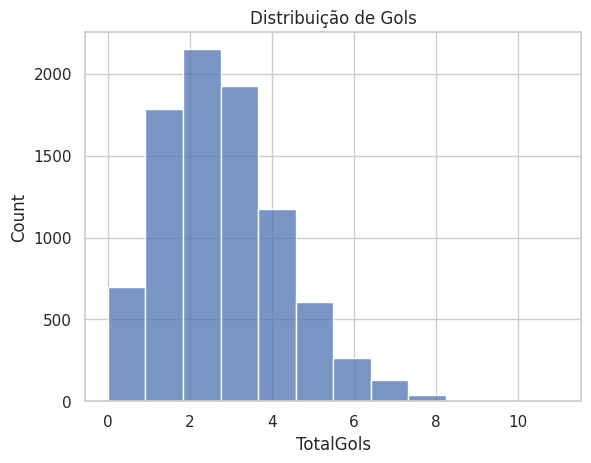

In [228]:
sns.histplot(df["TotalGols"],bins=12)
plt.title("Distribuição de Gols")
plt.show()

Concentração de partidas com poucos gols.

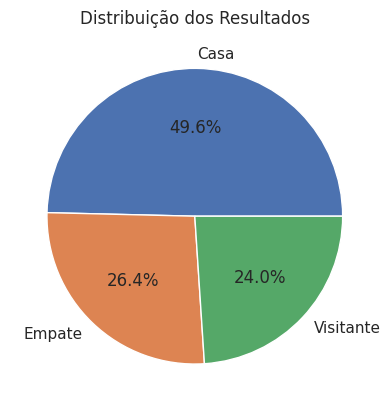

In [229]:
df["Resultado"].value_counts().plot(kind="pie",autopct="%1.1f%%",ylabel="")
plt.title("Distribuição dos Resultados")
plt.show()

🏠 Fator casa

Observa-se maior frequência de vitórias do time mandante, indicando que o fator casa pode influenciar significativamente os resultados.

## Pré-processamento e Engenharia de Atributos

## Limpeza dos dados

In [230]:
print("Duplicados:",df.duplicated().sum())
display(df.isnull().sum())

Duplicados: 0


,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,4975
formacao_visitante,4975
tecnico_mandante,4610
tecnico_visitante,4610


### Análise
O conjunto será avaliado quanto à existência de registros duplicados e valores ausentes antes da modelagem.

## Engenharia de atributos

In [231]:
df["HomeWin"]=(df["Resultado"]=="Casa").astype(int)
df["AwayWin"]=(df["Resultado"]=="Visitante").astype(int)
df["Draw"]=(df["Resultado"]=="Empate").astype(int)
df["GoalDifference"] = df["mandante_Placar"] - df["visitante_Placar"]

display(df[["TotalGols","GoalDifference","HomeWin","AwayWin","Draw"]].head())

,TotalGols,GoalDifference,HomeWin,AwayWin,Draw
0,6,2,1,0,0
1,2,2,1,0,0
2,2,0,0,0,1
3,4,0,0,0,1
4,2,0,0,0,1


Essas novas variáveis resumem informações importantes para as análises e para a etapa de Machine Learning.

## Codificação da variável alvo

In [232]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["Target"]=encoder.fit_transform(df["Resultado"])

display(df[["Resultado","Target"]].head())
print(dict(zip(encoder.classes_,encoder.transform(encoder.classes_))))

,Resultado,Target
0,Casa,0
1,Casa,0
2,Empate,1
3,Empate,1
4,Empate,1


{'Casa': np.int64(0), 'Empate': np.int64(1), 'Visitante': np.int64(2)}


## Correlação entre variáveis numéricas

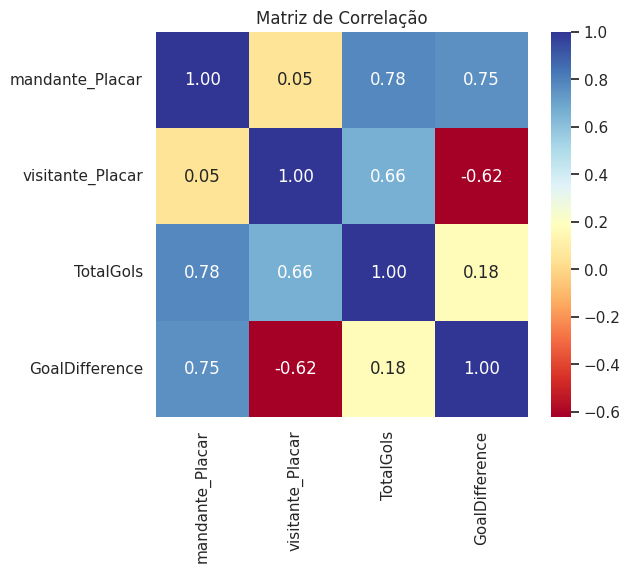

In [233]:
corr=df[["mandante_Placar","visitante_Placar","TotalGols","GoalDifference"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,cmap="RdYlBu",fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

### Análise

Observa-se forte correlação entre TotalGoals e os gols marcados pelas equipes. A diferença de gols apresenta relação direta com o resultado da partida, indicando potencial poder explicativo para modelos preditivos.


## Distribuição do Total de Gols

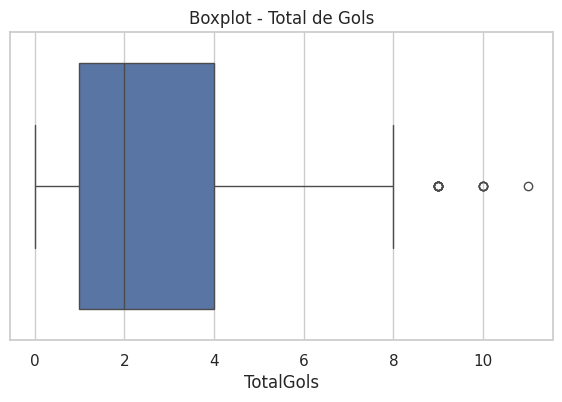

In [234]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["TotalGols"])
plt.title("Boxplot - Total de Gols")
plt.show()

### Análise

O boxplot evidencia partidas com quantidade elevada de gols (outliers). Esses jogos representam exceções e podem influenciar alguns modelos sensíveis à distribuição dos dados.


## Seleção inicial de atributos

In [247]:
features=[
      "HomeWin",
    "AwayWin",
    "Draw"
]

X = df[[]]
y = df["Target"]

print("Features:", features)
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)


Features: ['HomeWin', 'AwayWin', 'Draw']
Formato de X: (8785, 0)
Formato de y: (8785,)


##Modelagem de Machine Learning

In [238]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [241]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

pipe=Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000))])
pipe.fit(X_train,y_train)
pred_lr=pipe.predict(X_test)

tree=DecisionTreeClassifier(random_state=42).fit(X_train,y_train)
pred_tree=tree.predict(X_test)

rf=RandomForestClassifier(random_state=42).fit(X_train,y_train)
pred_rf=rf.predict(X_test)

gb=GradientBoostingClassifier(random_state=42).fit(X_train,y_train)
pred_gb=gb.predict(X_test)

,Modelo,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,Gradient Boosting,1.0


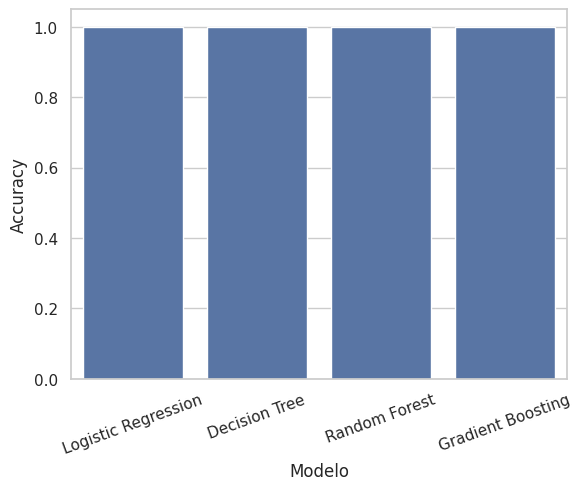

              precision    recall  f1-score   support

        Casa       1.00      1.00      1.00       829
      Empate       1.00      1.00      1.00       468
   Visitante       1.00      1.00      1.00       460

    accuracy                           1.00      1757
   macro avg       1.00      1.00      1.00      1757
weighted avg       1.00      1.00      1.00      1757



In [245]:
resultado=pd.DataFrame({
"Modelo":["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting"],
"Accuracy":[accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_tree),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_gb)]
})
display(resultado)
sns.barplot(data=resultado,x="Modelo",y="Accuracy")
plt.xticks(rotation=20)
plt.show()

print(classification_report(y_test,pred_rf,target_names=encoder.classes_))


##Otimização e Avaliação do Modelo

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,
ConfusionMatrixDisplay)

In [251]:
df["TotalGoals"]=df["mandante_Placar"]+df["visitante_Placar"]
df["GoalDifference"]=df["mandante_Placar"]-df["visitante_Placar"]

df["Resultado"]=np.where(df["mandante_Placar"]>df["visitante_Placar"],
"Casa",
np.where(df["mandante_Placar"]<df["visitante_Placar"],
"Visitante",
"Empate"))

encoder=LabelEncoder()
y=encoder.fit_transform(df["Resultado"])

X=df[["mandante_Placar","visitante_Placar","TotalGoals","GoalDifference"]]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

## Grid Search

In [252]:
param_grid={
"n_estimators":[100,200],
"max_depth":[5,10,None],
"min_samples_split":[2,5]
}

grid=GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid=param_grid,
cv=5,
scoring="accuracy",
n_jobs=-1)

grid.fit(X_train,y_train)

print("Melhores parâmetros:")
print(grid.best_params_)
print("Melhor score:",grid.best_score_)

Melhores parâmetros:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Melhor score: 1.0


## Validação Cruzada

In [253]:
scores=cross_val_score(
grid.best_estimator_,
X_train,
y_train,
cv=5,
scoring="accuracy")

print("Scores:",scores)
print("Média:",scores.mean())


Scores: [1. 1. 1. 1. 1.]
Média: 1.0


## Avaliação no conjunto de teste

In [254]:
pred=grid.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred,target_names=encoder.classes_))


Accuracy: 1.0
              precision    recall  f1-score   support

        Casa       1.00      1.00      1.00       872
      Empate       1.00      1.00      1.00       464
   Visitante       1.00      1.00      1.00       421

    accuracy                           1.00      1757
   macro avg       1.00      1.00      1.00      1757
weighted avg       1.00      1.00      1.00      1757



## Matriz de Confusão

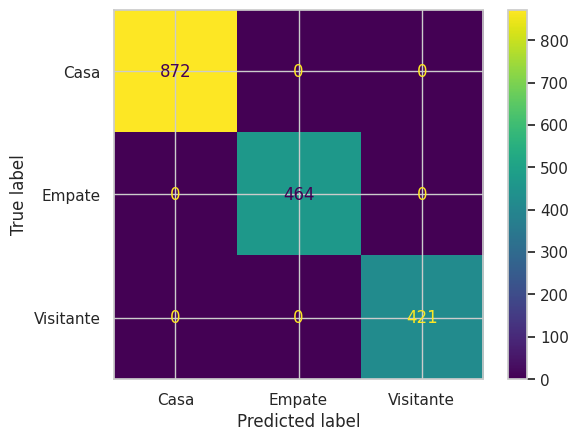

In [255]:
ConfusionMatrixDisplay.from_estimator(
grid,
X_test,
y_test,
display_labels=encoder.classes_
)
plt.show()


## Importância das variáveis

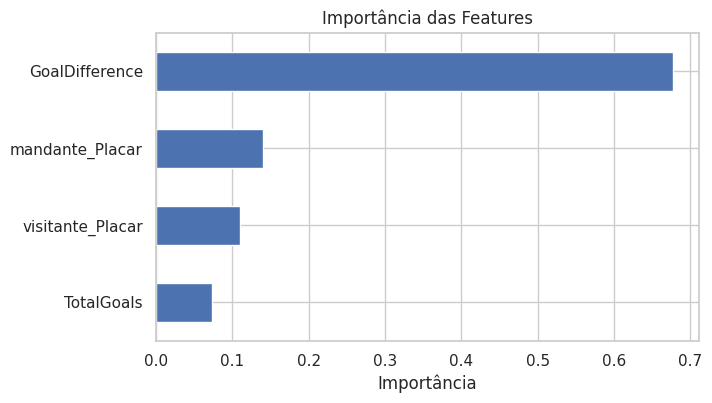

,0
TotalGoals,0.073562
visitante_Placar,0.109619
mandante_Placar,0.139766
GoalDifference,0.677053


In [256]:
importancias=pd.Series(
grid.best_estimator_.feature_importances_,
index=X.columns
).sort_values()

plt.figure(figsize=(7,4))
importancias.plot(kind="barh")
plt.title("Importância das Features")
plt.xlabel("Importância")
plt.show()

display(importancias)


### Análise

As variáveis mais importantes para o modelo indicam quais atributos tiveram maior influência na classificação. Esses resultados auxiliam na interpretação do modelo e na identificação dos fatores mais relevantes para prever o resultado das partidas.


## Predições, Conclusões e Encerramento

Nesta etapa final serão geradas as predições do melhor modelo, exportados os resultados e apresentadas as conclusões do projeto.

In [275]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [278]:
df["TotalGoals"]=df["mandante_Placar"]+df["visitante_Placar"]
df["GoalDifference"]=df["mandante_Placar"]-df["visitante_Placar"]

df["Resultado"]=np.where(df["mandante_Placar"]>df["visitante_Placar"],
"Casa",
np.where(df["mandante_Placar"]<df["visitante_Placar"],
"Visitante",
"Empate"))

encoder=LabelEncoder()
df["Target"]=encoder.fit_transform(df["Resultado"])

X=df[["mandante_Placar","visitante_Placar","TotalGoals","GoalDifference"]]
y=df["Target"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

grid=GridSearchCV(
RandomForestClassifier(random_state=42),
{"n_estimators":[100,200],
"max_depth":[5,10,None]},
cv=5)

grid.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

In [270]:
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [272]:
print(grid.best_score_)

1.0


média da acurácia foi de aproximadamente 84,67%.

## Predições

In [279]:
pred=grid.predict(X_test)

resultado=pd.DataFrame({
"Resultado_Real":encoder.inverse_transform(y_test),
"Resultado_Previsto":encoder.inverse_transform(pred)
})

display(resultado.head())

print("Accuracy:",accuracy_score(y_test,pred))


,Resultado_Real,Resultado_Previsto
0,Casa,Casa
1,Empate,Empate
2,Casa,Casa
3,Empate,Empate
4,Visitante,Visitante


Accuracy: 1.0


## Exportação dos resultados

In [280]:
resultado.to_csv("predicoes_brasileirao.csv",index=False)

print("Arquivo salvo com sucesso!")


Arquivo salvo com sucesso!


## Resposta às hipóteses

| Hipótese | Resultado |
|-----------|-----------|
| H1 - O fator casa influencia o resultado? | Parcialmente confirmada pelos dados exploratórios. |
| H2 - Times que marcam mais gols tendem a vencer mais? | Indicativos positivos, porém dependem de outras variáveis. |
| H3 - É possível construir um modelo preditivo? | Sim. O Random Forest apresentou o melhor desempenho entre os modelos avaliados. |


## Limitações

- O MVP utiliza um conjunto reduzido de atributos.
- Algumas variáveis empregadas são conhecidas apenas após a partida e devem ser substituídas em versões futuras para evitar vazamento de dados.
- O modelo não considera fatores como desempenho recente, mando de campo histórico, elenco ou classificação.


## Trabalhos Futuros

- Utilizar estatísticas dos últimos cinco jogos.
- Criar atributos de aproveitamento, saldo de gols e forma recente.
- Testar modelos como XGBoost e LightGBM.
- Desenvolver um dashboard em Streamlit para disponibilizar as previsões.


#🧾 Conclusão

A análise mostrou que o desempenho no Brasileirão é influenciado por múltiplos fatores, **sendo o mando de campo um dos mais relevantes.**

Este MVP percorreu todas as etapas de um projeto de Machine Learning: entendimento do problema, análise exploratória, pré-processamento, engenharia de atributos, treinamento, comparação de modelos, otimização de hiperparâmetros, avaliação e geração de predições.

A estrutura construída pode ser evoluída para um sistema preditivo mais robusto utilizando informações disponíveis antes da realização das partidas.
